# Ordinal Wine Quality Prediction

## Goal

This notebook predicts white-wine quality from physicochemical measurements.

Wine quality is an ordinal target.

The possible labels have a meaningful order:

`lower quality < medium quality < higher quality`

This means that prediction errors have different levels of severity.

For example:

- Predicting quality 6 instead of 7 is a one-level error
- Predicting quality 3 instead of 7 is a four-level error

Ordinary multiclass classification does not represent this distinction directly.

## Models

### Constant baseline

Always predicts the most common training quality.

### Multiclass neural network

Predicts one probability for every quality level using cross-entropy loss.

It treats all quality classes as separate categories.

### Regression neural network

Predicts one continuous quality score using mean squared error.

The output is rounded to the nearest observed quality level.

### Ordinal threshold network

Learns:

- one latent quality score for each wine
- a set of ordered boundaries between quality levels

For each wine, it estimates whether its quality exceeds each boundary.

## Main question

Does explicitly modelling the order between quality classes produce more sensible predictions than ordinary classification or regression?

In [1]:
import copy
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    DataLoader
)

from sklearn.model_selection import (
    train_test_split
)

from sklearn.preprocessing import (
    StandardScaler
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    mean_absolute_error,
    cohen_kappa_score,
    confusion_matrix
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

BATCH_SIZE = 128
MAXIMUM_EPOCHS = 50
EARLY_STOPPING_PATIENCE = 7

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


set_seed(RANDOM_STATE)

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)
print("PyTorch version:", torch.__version__)

Device: cuda
PyTorch version: 2.5.1+cu124


In [72]:
dataset_url = (
    "https://archive.ics.uci.edu/"
    "ml/machine-learning-databases/"
    "wine-quality/"
    "winequality-white.csv"
)

fallback_df = pd.read_csv(
    dataset_url,
    sep=";"
)

feature_df = fallback_df.drop(
    columns=["quality"]
)

target_series = fallback_df[
    "quality"
]

data_source = "Official UCI CSV"

In [3]:
feature_df.columns = [
    column_name
    .strip()
    .lower()
    .replace(" ", "_")
    for column_name
    in feature_df.columns
]

target_series = pd.to_numeric(
    target_series,
    errors="coerce"
)

wine_df = pd.concat(
    [
        feature_df.reset_index(drop=True),
        target_series
        .rename("quality")
        .reset_index(drop=True)
    ],
    axis=1
)

wine_df = wine_df.dropna().reset_index(
    drop=True
)

wine_df["quality"] = (
    wine_df["quality"].astype(int)
)

print("Data source:", data_source)
print("Dataset shape:", wine_df.shape)

wine_df.head()

Data source: Official UCI CSV
Dataset shape: (4898, 12)


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [4]:
feature_columns = [
    column
    for column in wine_df.columns
    if column != "quality"
]

quality_counts = (
    wine_df["quality"]
    .value_counts()
    .sort_index()
)

quality_distribution_df = (
    quality_counts
    .rename_axis("quality")
    .reset_index(name="observations")
)

quality_distribution_df[
    "percentage"
] = (
    quality_distribution_df[
        "observations"
    ]
    / len(wine_df)
    * 100
)

quality_distribution_df

,quality,observations,percentage
0,3,20,0.408330
1,4,163,3.327889
2,5,1457,29.746835
3,6,2198,44.875459
4,7,880,17.966517
5,8,175,3.572887
6,9,5,0.102082


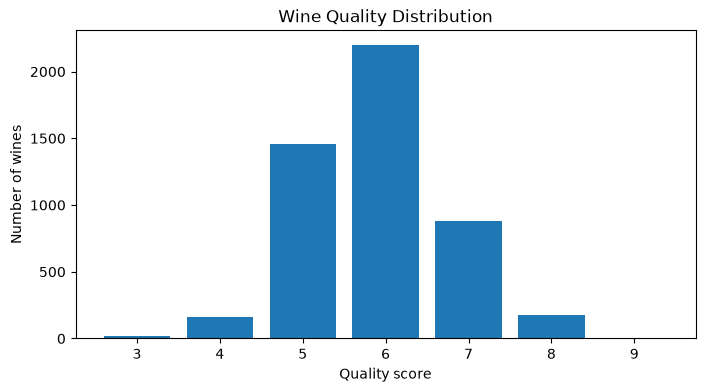

In [5]:
plt.figure(figsize=(8, 4))

plt.bar(
    quality_distribution_df[
        "quality"
    ].astype(str),
    quality_distribution_df[
        "observations"
    ]
)

plt.title(
    "Wine Quality Distribution"
)

plt.xlabel("Quality score")
plt.ylabel("Number of wines")
plt.show()

In [6]:
wine_df[
    feature_columns
].describe().T

,count,mean,std,min,25%,50%,75%,max
fixed_acidity,4898.0,6.854788,0.843868,3.80000,6.300000,6.80000,7.3000,14.20000
volatile_acidity,4898.0,0.278241,0.100795,0.08000,0.210000,0.26000,0.3200,1.10000
citric_acid,4898.0,0.334192,0.121020,0.00000,0.270000,0.32000,0.3900,1.66000
residual_sugar,4898.0,6.391415,5.072058,0.60000,1.700000,5.20000,9.9000,65.80000
chlorides,4898.0,0.045772,0.021848,0.00900,0.036000,0.04300,0.0500,0.34600
free_sulfur_dioxide,4898.0,35.308085,17.007137,2.00000,23.000000,34.00000,46.0000,289.00000
total_sulfur_dioxide,4898.0,138.360657,42.498065,9.00000,108.000000,134.00000,167.0000,440.00000
density,4898.0,0.994027,0.002991,0.98711,0.991723,0.99374,0.9961,1.03898
ph,4898.0,3.188267,0.151001,2.72000,3.090000,3.18000,3.2800,3.82000
sulphates,4898.0,0.489847,0.114126,0.22000,0.410000,0.47000,0.5500,1.08000


In [7]:
print(
    "Missing values:",
    wine_df.isna().sum().sum()
)

print(
    "Observed qualities:",
    sorted(
        wine_df["quality"].unique()
    )
)

Missing values: 0
Observed qualities: [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


## Dataset inspection 

The white-wine dataset contained:

- 4,898 observations
- 11 physicochemical features
- 1 ordinal target
- No missing values

Observed quality levels ranged from 3 to 9.

Their distribution was:

| Quality | Observations | Percentage |
|---:|---:|---:|
| 3 | 20 | 0.41% |
| 4 | 163 | 3.33% |
| 5 | 1,457 | 29.75% |
| 6 | 2,198 | 44.88% |
| 7 | 880 | 17.97% |
| 8 | 175 | 3.57% |
| 9 | 5 | 0.10% |

Quality 6 was by far the most common class, while qualities 3 and 9 were extremely rare.

Approximately 74.6% of all wines had quality 5 or 6. A model could therefore obtain reasonable exact accuracy by concentrating predictions around the middle of the scale while performing poorly on rare low- and high-quality wines.

This makes balanced accuracy, Mean Absolute Error, Quadratic Weighted Kappa, and severe-error rate important alongside ordinary accuracy.

In [8]:
quality_values = np.array(
    sorted(
        wine_df["quality"].unique()
    )
)

quality_to_rank = {
    int(quality): rank
    for rank, quality
    in enumerate(quality_values)
}

rank_to_quality = {
    rank: int(quality)
    for rank, quality
    in enumerate(quality_values)
}

wine_df["quality_rank"] = (
    wine_df["quality"]
    .map(quality_to_rank)
    .astype(int)
)

NUMBER_OF_QUALITY_LEVELS = len(
    quality_values
)

NUMBER_OF_THRESHOLDS = (
    NUMBER_OF_QUALITY_LEVELS - 1
)

print("Quality values:", quality_values)
print("Quality-to-rank mapping:", quality_to_rank)
print("Ordinal thresholds:", NUMBER_OF_THRESHOLDS)

Quality values: [3 4 5 6 7 8 9]
Quality-to-rank mapping: {3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5, 9: 6}
Ordinal thresholds: 6


In [9]:
X = wine_df[
    feature_columns
].copy()

y_rank = wine_df[
    "quality_rank"
].copy()

In [10]:
(
    X_train_validation,
    X_test,
    y_train_validation,
    y_test
) = train_test_split(
    X,
    y_rank,
    test_size=0.15,
    random_state=RANDOM_STATE,
    stratify=y_rank
)

In [11]:
validation_fraction_of_remaining = (
    0.15 / 0.85
)

(
    X_train,
    X_validation,
    y_train,
    y_validation
) = train_test_split(
    X_train_validation,
    y_train_validation,
    test_size=
        validation_fraction_of_remaining,
    random_state=RANDOM_STATE,
    stratify=y_train_validation
)

In [12]:
split_summary_df = pd.DataFrame({
    "split": [
        "Training",
        "Validation",
        "Test"
    ],
    "observations": [
        len(X_train),
        len(X_validation),
        len(X_test)
    ],
    "percentage": [
        len(X_train) / len(X),
        len(X_validation) / len(X),
        len(X_test) / len(X)
    ]
})

split_summary_df

,split,observations,percentage
0,Training,3428,0.699878
1,Validation,735,0.150061
2,Test,735,0.150061


In [13]:
split_quality_distribution = pd.concat(
    [
        y_train.value_counts(
            normalize=True
        ).sort_index().rename(
            "Training"
        ),

        y_validation.value_counts(
            normalize=True
        ).sort_index().rename(
            "Validation"
        ),

        y_test.value_counts(
            normalize=True
        ).sort_index().rename(
            "Test"
        )
    ],
    axis=1
)

split_quality_distribution.index = [
    rank_to_quality[int(rank)]
    for rank in
    split_quality_distribution.index
]

split_quality_distribution

,Training,Validation,Test
3,0.004084,0.004082,0.004082
4,0.033547,0.032653,0.032653
5,0.297258,0.297959,0.297959
6,0.448658,0.448980,0.448980
7,0.179697,0.179592,0.179592
8,0.035881,0.035374,0.035374
9,0.000875,0.001361,0.001361


## Data split 

The stratified split produced:

| Split | Observations | Percentage |
|---|---:|---:|
| Training | 3,428 | 69.99% |
| Validation | 735 | 15.01% |
| Test | 735 | 15.01% |

Stratification preserved similar class proportions across all three sets.

However, the extreme classes remained very small:

- Quality 3: 14 training, 3 validation, and 3 test wines
- Quality 9: 3 training, 1 validation, and 1 test wine

Metrics for these extreme qualities are therefore highly unstable. A single correct or incorrect prediction can change their class-level result substantially.

The validation set was used for model selection and early stopping, while the test set remained separate until final evaluation.

In [14]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_validation_scaled = scaler.transform(
    X_validation
)

X_test_scaled = scaler.transform(
    X_test
)

In [15]:
scaled_feature_summary_df = pd.DataFrame(
    X_train_scaled,
    columns=feature_columns
).agg(["mean", "std"]).T

scaled_feature_summary_df

,mean,std
fixed_acidity,-6.011009e-17,1.000146
volatile_acidity,3.979703e-16,1.000146
citric_acid,-5.751914e-16,1.000146
residual_sugar,-2.383676e-17,1.000146
chlorides,1.140019e-17,1.000146
free_sulfur_dioxide,-1.720392e-16,1.000146
total_sulfur_dioxide,-2.611680e-16,1.000146
density,-2.057838e-14,1.000146
ph,-3.627333e-15,1.000146
sulphates,-4.145524e-17,1.000146


## Feature scaling 

The StandardScaler was fitted only on the 3,428 training observations.

After transformation, the training features had approximately:

- Mean: 0
- Standard deviation: 1

The training means and standard deviations were then reused for validation and test data.

This prevented information from the validation or test distributions from influencing preprocessing and ensured that features measured on very different numerical scales contributed more comparably during neural-network training.

In [16]:
training_class_counts = np.bincount(
    y_train.to_numpy(),
    minlength=
        NUMBER_OF_QUALITY_LEVELS
)

class_balance_weights = (
    len(y_train)
    / (
        NUMBER_OF_QUALITY_LEVELS
        * training_class_counts
    )
)

class_weight_df = pd.DataFrame({
    "quality": quality_values,
    "training_observations":
        training_class_counts,
    "sample_weight":
        class_balance_weights
})

class_weight_df

,quality,training_observations,sample_weight
0,3,14,34.979592
1,4,115,4.258385
2,5,1019,0.480583
3,6,1538,0.318410
4,7,616,0.794991
5,8,123,3.981417
6,9,3,163.238095


In [17]:
training_sample_weights = (
    class_balance_weights[
        y_train.to_numpy()
    ]
)

## Class balancing 

Inverse-frequency sample weighting assigned much larger losses to rare quality levels.

Selected weights were:

| Quality | Training observations | Sample weight |
|---:|---:|---:|
| 3 | 14 | 34.9796 |
| 4 | 115 | 4.2584 |
| 5 | 1,019 | 0.4806 |
| 6 | 1,538 | 0.3184 |
| 7 | 616 | 0.7950 |
| 8 | 123 | 3.9814 |
| 9 | 3 | 163.2381 |

A quality-9 observation contributed more than 500 times the weight of a quality-6 observation.

This weighting encouraged the models not to ignore rare extreme qualities. However, the extremely large weight assigned to the three quality-9 training examples could also make optimisation unstable and encourage occasional extreme predictions based on very limited evidence.

The weighting improved attention to minority levels but changed the effective training distribution away from the real class frequencies.

In [18]:
class WineQualityDataset(Dataset):
    def __init__(
        self,
        features,
        ranks,
        sample_weights=None
    ):
        self.features = torch.tensor(
            np.asarray(features),
            dtype=torch.float32
        )

        self.ranks = torch.tensor(
            np.asarray(ranks),
            dtype=torch.long
        )

        if sample_weights is None:
            sample_weights = np.ones(
                len(self.ranks),
                dtype=np.float32
            )

        self.sample_weights = torch.tensor(
            np.asarray(sample_weights),
            dtype=torch.float32
        )

    def __len__(self):
        return len(self.ranks)

    def __getitem__(self, index):
        return (
            self.features[index],
            self.ranks[index],
            self.sample_weights[index]
        )

In [19]:
training_dataset = WineQualityDataset(
    X_train_scaled,
    y_train.to_numpy(),
    training_sample_weights
)

validation_dataset = WineQualityDataset(
    X_validation_scaled,
    y_validation.to_numpy()
)

test_dataset = WineQualityDataset(
    X_test_scaled,
    y_test.to_numpy()
)

In [20]:
training_loader = DataLoader(
    training_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

In [21]:
def ranks_to_qualities(ranks):
    ranks = np.asarray(
        ranks,
        dtype=int
    )

    return quality_values[ranks]

In [22]:
def calculate_ordinal_metrics(
    true_ranks,
    predicted_ranks
):
    true_ranks = np.asarray(
        true_ranks,
        dtype=int
    )

    predicted_ranks = np.asarray(
        predicted_ranks,
        dtype=int
    )

    true_qualities = ranks_to_qualities(
        true_ranks
    )

    predicted_qualities = (
        ranks_to_qualities(
            predicted_ranks
        )
    )

    absolute_errors = np.abs(
        predicted_qualities
        - true_qualities
    )

    return {
        "accuracy":
            accuracy_score(
                true_ranks,
                predicted_ranks
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                true_ranks,
                predicted_ranks
            ),

        "mean_absolute_error":
            mean_absolute_error(
                true_qualities,
                predicted_qualities
            ),

        "within_one_accuracy":
            np.mean(
                absolute_errors <= 1
            ),

        "severe_error_rate":
            np.mean(
                absolute_errors >= 2
            ),

        "quadratic_weighted_kappa":
            cohen_kappa_score(
                true_ranks,
                predicted_ranks,
                weights="quadratic"
            )
    }

In [23]:
most_common_training_rank = int(
    y_train.value_counts().idxmax()
)

most_common_training_quality = (
    rank_to_quality[
        most_common_training_rank
    ]
)

baseline_predictions = np.full(
    len(y_test),
    fill_value=
        most_common_training_rank,
    dtype=int
)

baseline_metrics = (
    calculate_ordinal_metrics(
        y_test.to_numpy(),
        baseline_predictions
    )
)

print(
    "Constant predicted quality:",
    most_common_training_quality
)

pd.DataFrame({
    "metric": list(
        baseline_metrics.keys()
    ),
    "value": list(
        baseline_metrics.values()
    )
})

Constant predicted quality: 6


,metric,value
0,accuracy,0.448980
1,balanced_accuracy,0.142857
2,mean_absolute_error,0.629932
3,within_one_accuracy,0.926531
4,severe_error_rate,0.073469
5,quadratic_weighted_kappa,0.000000


## Constant baseline 

The constant baseline always predicted quality 6, the most common training quality.

It achieved:

- Exact accuracy: 0.4490
- Balanced accuracy: 0.1429
- Mean Absolute Error: 0.6299
- Within-one accuracy: 0.9265
- Severe-error rate: 0.0735
- Quadratic Weighted Kappa: 0.0000

The baseline achieved the highest exact accuracy by a very small margin because 44.9% of the test wines genuinely had quality 6.

Its within-one accuracy was also high because most test wines had quality 5, 6, or 7.

However, its QWK was zero and its balanced accuracy was only 1/7. It did not distinguish individual wines or provide any useful ordering. Every observation received exactly the same prediction and ranking score.

This demonstrates that accuracy, MAE, and within-one accuracy can all appear deceptively strong when an ordinal target is heavily concentrated around one central class.

In [24]:
class WineFeatureBackbone(nn.Module):
    def __init__(
        self,
        number_of_features
    ):
        super().__init__()

        self.layers = nn.Sequential(
            nn.Linear(
                number_of_features,
                64
            ),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.20),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.10)
        )

    def forward(self, features):
        return self.layers(features)

In [25]:
class MulticlassQualityModel(nn.Module):
    def __init__(
        self,
        number_of_features,
        number_of_classes
    ):
        super().__init__()

        self.backbone = (
            WineFeatureBackbone(
                number_of_features
            )
        )

        self.output_layer = nn.Linear(
            32,
            number_of_classes
        )

    def forward(self, features):
        hidden_features = (
            self.backbone(features)
        )

        return self.output_layer(
            hidden_features
        )

In [26]:
class RegressionQualityModel(nn.Module):
    def __init__(
        self,
        number_of_features
    ):
        super().__init__()

        self.backbone = (
            WineFeatureBackbone(
                number_of_features
            )
        )

        self.output_layer = nn.Linear(
            32,
            1
        )

    def forward(self, features):
        hidden_features = (
            self.backbone(features)
        )

        return (
            self.output_layer(
                hidden_features
            )
            .squeeze(1)
        )

In [27]:
class OrdinalThresholdQualityModel(
    nn.Module
):
    def __init__(
        self,
        number_of_features,
        number_of_levels
    ):
        super().__init__()

        self.number_of_levels = (
            number_of_levels
        )

        self.backbone = (
            WineFeatureBackbone(
                number_of_features
            )
        )

        self.score_layer = nn.Linear(
            32,
            1
        )

        self.first_cutpoint = (
            nn.Parameter(
                torch.tensor(-1.5)
            )
        )

        number_of_gaps = (
            number_of_levels - 2
        )

        if number_of_gaps > 0:
            self.raw_cutpoint_gaps = (
                nn.Parameter(
                    torch.full(
                        (
                            number_of_gaps,
                        ),
                        -0.4
                    )
                )
            )
        else:
            self.raw_cutpoint_gaps = None

    def ordered_cutpoints(self):
        if self.raw_cutpoint_gaps is None:
            return (
                self.first_cutpoint
                .reshape(1)
            )

        positive_gaps = (
            F.softplus(
                self.raw_cutpoint_gaps
            )
            + 0.05
        )

        later_cutpoints = (
            self.first_cutpoint
            + torch.cumsum(
                positive_gaps,
                dim=0
            )
        )

        return torch.cat(
            [
                self.first_cutpoint
                .reshape(1),
                later_cutpoints
            ]
        )

    def latent_score(self, features):
        hidden_features = (
            self.backbone(features)
        )

        return (
            self.score_layer(
                hidden_features
            )
            .squeeze(1)
        )

    def forward(self, features):
        score = self.latent_score(
            features
        )

        cutpoints = (
            self.ordered_cutpoints()
        )

        threshold_logits = (
            score.unsqueeze(1)
            - cutpoints.unsqueeze(0)
        )

        return threshold_logits

In [28]:
def create_threshold_targets(
    ranks,
    number_of_levels
):
    threshold_indices = torch.arange(
        number_of_levels - 1,
        device=ranks.device
    )

    return (
        ranks.unsqueeze(1)
        > threshold_indices.unsqueeze(0)
    ).float()

In [29]:
example_ranks = torch.tensor([
    0,
    2,
    NUMBER_OF_QUALITY_LEVELS - 1
])

example_threshold_targets = (
    create_threshold_targets(
        example_ranks,
        NUMBER_OF_QUALITY_LEVELS
    )
)

pd.DataFrame(
    example_threshold_targets.numpy(),
    index=[
        f"Rank {int(rank)}"
        for rank in example_ranks
    ],
    columns=[
        f"Greater than rank {rank}"
        for rank in range(
            NUMBER_OF_THRESHOLDS
        )
    ]
)

,Greater than rank 0,Greater than rank 1,Greater than rank 2,Greater than rank 3,Greater than rank 4,Greater than rank 5
Rank 0,0.0,0.0,0.0,0.0,0.0,0.0
Rank 2,1.0,1.0,0.0,0.0,0.0,0.0
Rank 6,1.0,1.0,1.0,1.0,1.0,1.0


## Cumulative target 

Each quality rank was converted into a sequence of binary threshold targets.

For example, a wine with rank 3 produced:

`1, 1, 1, 0, 0, 0`

This means that its quality was:

- greater than rank 0
- greater than rank 1
- greater than rank 2
- not greater than rank 3 or any higher boundary

This representation preserves the order of the target.

A high-quality wine must exceed all lower boundaries before it can exceed a higher one. The model therefore learns a structured set of ordered comparisons rather than seven unrelated class probabilities.

In [30]:
def calculate_weighted_loss(
    outputs,
    target_ranks,
    sample_weights,
    model_type
):
    if model_type == "Multiclass":
        per_sample_loss = (
            F.cross_entropy(
                outputs,
                target_ranks,
                reduction="none"
            )
        )

    elif model_type == "Regression":
        per_sample_loss = (
            F.mse_loss(
                outputs,
                target_ranks.float(),
                reduction="none"
            )
        )

    elif model_type == "Ordinal":
        threshold_targets = (
            create_threshold_targets(
                target_ranks,
                NUMBER_OF_QUALITY_LEVELS
            )
        )

        per_threshold_loss = (
            F.binary_cross_entropy_with_logits(
                outputs,
                threshold_targets,
                reduction="none"
            )
        )

        per_sample_loss = (
            per_threshold_loss.mean(
                dim=1
            )
        )

    else:
        raise ValueError(
            f"Unknown model type: "
            f"{model_type}"
        )

    return (
        per_sample_loss
        * sample_weights
    ).sum() / sample_weights.sum()

In [31]:
def decode_outputs(
    outputs,
    model_type
):
    if model_type == "Multiclass":
        predicted_ranks = (
            outputs.argmax(dim=1)
        )

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        rank_values = torch.arange(
            NUMBER_OF_QUALITY_LEVELS,
            device=outputs.device,
            dtype=torch.float32
        )

        ordering_scores = (
            probabilities
            * rank_values.unsqueeze(0)
        ).sum(dim=1)

    elif model_type == "Regression":
        ordering_scores = outputs

        predicted_ranks = (
            torch.round(outputs)
            .long()
            .clamp(
                0,
                NUMBER_OF_QUALITY_LEVELS - 1
            )
        )

    elif model_type == "Ordinal":
        threshold_probabilities = (
            torch.sigmoid(outputs)
        )

        predicted_ranks = (
            threshold_probabilities
            .gt(0.5)
            .sum(dim=1)
        )

        ordering_scores = (
            threshold_probabilities
            .sum(dim=1)
        )

    else:
        raise ValueError(
            f"Unknown model type: "
            f"{model_type}"
        )

    return (
        predicted_ranks,
        ordering_scores
    )

In [32]:
@torch.no_grad()
def evaluate_quality_model(
    model,
    data_loader,
    model_type
):
    model.eval()

    losses = []

    all_true_ranks = []
    all_predicted_ranks = []
    all_ordering_scores = []

    for (
        features,
        target_ranks,
        sample_weights
    ) in data_loader:
        features = features.to(device)

        target_ranks_device = (
            target_ranks.to(device)
        )

        sample_weights_device = (
            sample_weights.to(device)
        )

        outputs = model(features)

        loss = calculate_weighted_loss(
            outputs,
            target_ranks_device,
            sample_weights_device,
            model_type
        )

        (
            predicted_ranks,
            ordering_scores
        ) = decode_outputs(
            outputs,
            model_type
        )

        losses.append(
            loss.item()
        )

        all_true_ranks.extend(
            target_ranks.numpy()
        )

        all_predicted_ranks.extend(
            predicted_ranks
            .cpu()
            .numpy()
        )

        all_ordering_scores.extend(
            ordering_scores
            .cpu()
            .numpy()
        )

    metrics = calculate_ordinal_metrics(
        all_true_ranks,
        all_predicted_ranks
    )

    metrics["loss"] = float(
        np.mean(losses)
    )

    return {
        "metrics": metrics,
        "true_ranks":
            np.asarray(
                all_true_ranks
            ),
        "predicted_ranks":
            np.asarray(
                all_predicted_ranks
            ),
        "ordering_scores":
            np.asarray(
                all_ordering_scores
            )
    }

In [33]:
def train_quality_model(
    model,
    model_type
):
    model = model.to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )

    scheduler = (
        torch.optim.lr_scheduler
        .ReduceLROnPlateau(
            optimizer,
            mode="max",
            factor=0.5,
            patience=2
        )
    )

    best_model_state = None
    best_validation_kappa = -np.inf
    best_validation_mae = np.inf

    epochs_without_improvement = 0

    history_rows = []

    for epoch in range(
        1,
        MAXIMUM_EPOCHS + 1
    ):
        model.train()

        running_loss = 0.0
        batches_seen = 0

        for (
            features,
            target_ranks,
            sample_weights
        ) in training_loader:
            features = features.to(device)

            target_ranks = (
                target_ranks.to(device)
            )

            sample_weights = (
                sample_weights.to(device)
            )

            optimizer.zero_grad()

            outputs = model(features)

            loss = calculate_weighted_loss(
                outputs,
                target_ranks,
                sample_weights,
                model_type
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=5.0
            )

            optimizer.step()

            running_loss += loss.item()
            batches_seen += 1

        training_loss = (
            running_loss
            / batches_seen
        )

        validation_result = (
            evaluate_quality_model(
                model,
                validation_loader,
                model_type
            )
        )

        validation_metrics = (
            validation_result["metrics"]
        )

        validation_kappa = (
            validation_metrics[
                "quadratic_weighted_kappa"
            ]
        )

        validation_mae = (
            validation_metrics[
                "mean_absolute_error"
            ]
        )

        if np.isnan(validation_kappa):
            validation_kappa = -1.0

        scheduler.step(
            validation_kappa
        )

        history_rows.append({
            "epoch": epoch,
            "training_loss":
                training_loss,
            "validation_loss":
                validation_metrics[
                    "loss"
                ],
            "validation_accuracy":
                validation_metrics[
                    "accuracy"
                ],
            "validation_balanced_accuracy":
                validation_metrics[
                    "balanced_accuracy"
                ],
            "validation_mae":
                validation_mae,
            "validation_within_one":
                validation_metrics[
                    "within_one_accuracy"
                ],
            "validation_qwk":
                validation_kappa,
            "learning_rate":
                optimizer.param_groups[0][
                    "lr"
                ]
        })

        print(
            f"{model_type:10s} | "
            f"Epoch {epoch:02d} | "
            f"Train loss "
            f"{training_loss:.4f} | "
            f"Val accuracy "
            f"{validation_metrics['accuracy']:.4f} | "
            f"Val MAE "
            f"{validation_mae:.4f} | "
            f"Val QWK "
            f"{validation_kappa:.4f}"
        )

        improved = (
            validation_kappa
            > best_validation_kappa
            + 1e-5
            or (
                np.isclose(
                    validation_kappa,
                    best_validation_kappa,
                    atol=1e-5
                )
                and validation_mae
                < best_validation_mae
            )
        )

        if improved:
            best_validation_kappa = (
                validation_kappa
            )

            best_validation_mae = (
                validation_mae
            )

            best_model_state = (
                copy.deepcopy(
                    model.state_dict()
                )
            )

            epochs_without_improvement = 0

        else:
            epochs_without_improvement += 1

        if (
            epochs_without_improvement
            >= EARLY_STOPPING_PATIENCE
        ):
            print(
                f"{model_type} early stopping."
            )
            break

    if best_model_state is not None:
        model.load_state_dict(
            best_model_state
        )

    history_df = pd.DataFrame(
        history_rows
    )

    return (
        model,
        history_df,
        best_validation_kappa
    )

In [34]:
number_of_features = len(
    feature_columns
)

multiclass_model = (
    MulticlassQualityModel(
        number_of_features,
        NUMBER_OF_QUALITY_LEVELS
    )
)

regression_model = (
    RegressionQualityModel(
        number_of_features
    )
)

ordinal_model = (
    OrdinalThresholdQualityModel(
        number_of_features,
        NUMBER_OF_QUALITY_LEVELS
    )
)

In [35]:
(
    multiclass_model,
    multiclass_history,
    multiclass_best_validation_kappa
) = train_quality_model(
    multiclass_model,
    "Multiclass"
)

Multiclass | Epoch 01 | Train loss 1.9338 | Val accuracy 0.1075 | Val MAE 1.6993 | Val QWK 0.1240
Multiclass | Epoch 02 | Train loss 1.8416 | Val accuracy 0.2408 | Val MAE 1.1660 | Val QWK 0.3349
Multiclass | Epoch 03 | Train loss 1.7737 | Val accuracy 0.2816 | Val MAE 1.0680 | Val QWK 0.3535
Multiclass | Epoch 04 | Train loss 1.6954 | Val accuracy 0.2558 | Val MAE 1.1415 | Val QWK 0.3468
Multiclass | Epoch 05 | Train loss 1.6703 | Val accuracy 0.2531 | Val MAE 1.2163 | Val QWK 0.3317
Multiclass | Epoch 06 | Train loss 1.5896 | Val accuracy 0.2762 | Val MAE 1.1755 | Val QWK 0.3310
Multiclass | Epoch 07 | Train loss 1.5740 | Val accuracy 0.2857 | Val MAE 1.1565 | Val QWK 0.3448
Multiclass | Epoch 08 | Train loss 1.5445 | Val accuracy 0.2966 | Val MAE 1.1333 | Val QWK 0.3387
Multiclass | Epoch 09 | Train loss 1.5486 | Val accuracy 0.2952 | Val MAE 1.1279 | Val QWK 0.3383
Multiclass | Epoch 10 | Train loss 1.5035 | Val accuracy 0.3102 | Val MAE 1.0993 | Val QWK 0.3480
Multiclass early sto

In [36]:
(
    regression_model,
    regression_history,
    regression_best_validation_kappa
) = train_quality_model(
    regression_model,
    "Regression"
)

Regression | Epoch 01 | Train loss 8.1885 | Val accuracy 0.0680 | Val MAE 1.7592 | Val QWK -0.0050
Regression | Epoch 02 | Train loss 4.4643 | Val accuracy 0.3238 | Val MAE 0.9143 | Val QWK 0.1655
Regression | Epoch 03 | Train loss 3.5271 | Val accuracy 0.3701 | Val MAE 0.8327 | Val QWK 0.2614
Regression | Epoch 04 | Train loss 3.1153 | Val accuracy 0.3578 | Val MAE 0.8544 | Val QWK 0.3296
Regression | Epoch 05 | Train loss 3.5140 | Val accuracy 0.3891 | Val MAE 0.7905 | Val QWK 0.3430
Regression | Epoch 06 | Train loss 3.0442 | Val accuracy 0.4109 | Val MAE 0.7755 | Val QWK 0.3656
Regression | Epoch 07 | Train loss 3.0003 | Val accuracy 0.3796 | Val MAE 0.7973 | Val QWK 0.3449
Regression | Epoch 08 | Train loss 2.7339 | Val accuracy 0.3918 | Val MAE 0.7850 | Val QWK 0.3843
Regression | Epoch 09 | Train loss 2.4983 | Val accuracy 0.4068 | Val MAE 0.7497 | Val QWK 0.3852
Regression | Epoch 10 | Train loss 2.7364 | Val accuracy 0.3973 | Val MAE 0.7728 | Val QWK 0.3914
Regression | Epoch 

In [37]:
(
    ordinal_model,
    ordinal_history,
    ordinal_best_validation_kappa
) = train_quality_model(
    ordinal_model,
    "Ordinal"
)

Ordinal    | Epoch 01 | Train loss 0.5164 | Val accuracy 0.4844 | Val MAE 0.5891 | Val QWK 0.3324
Ordinal    | Epoch 02 | Train loss 0.4871 | Val accuracy 0.4639 | Val MAE 0.6204 | Val QWK 0.4507
Ordinal    | Epoch 03 | Train loss 0.4543 | Val accuracy 0.4327 | Val MAE 0.6830 | Val QWK 0.4991
Ordinal    | Epoch 04 | Train loss 0.4537 | Val accuracy 0.3973 | Val MAE 0.7510 | Val QWK 0.4888
Ordinal    | Epoch 05 | Train loss 0.4476 | Val accuracy 0.3687 | Val MAE 0.7946 | Val QWK 0.5049
Ordinal    | Epoch 06 | Train loss 0.4428 | Val accuracy 0.3687 | Val MAE 0.8068 | Val QWK 0.4992
Ordinal    | Epoch 07 | Train loss 0.4336 | Val accuracy 0.3456 | Val MAE 0.8476 | Val QWK 0.4939
Ordinal    | Epoch 08 | Train loss 0.4328 | Val accuracy 0.3456 | Val MAE 0.8544 | Val QWK 0.4813
Ordinal    | Epoch 09 | Train loss 0.4279 | Val accuracy 0.3469 | Val MAE 0.8435 | Val QWK 0.4965
Ordinal    | Epoch 10 | Train loss 0.4225 | Val accuracy 0.3701 | Val MAE 0.8231 | Val QWK 0.4994
Ordinal    | Epoch 1

In [38]:
training_histories = {
    "Multiclass":
        multiclass_history,
    "Regression":
        regression_history,
    "Ordinal":
        ordinal_history
}

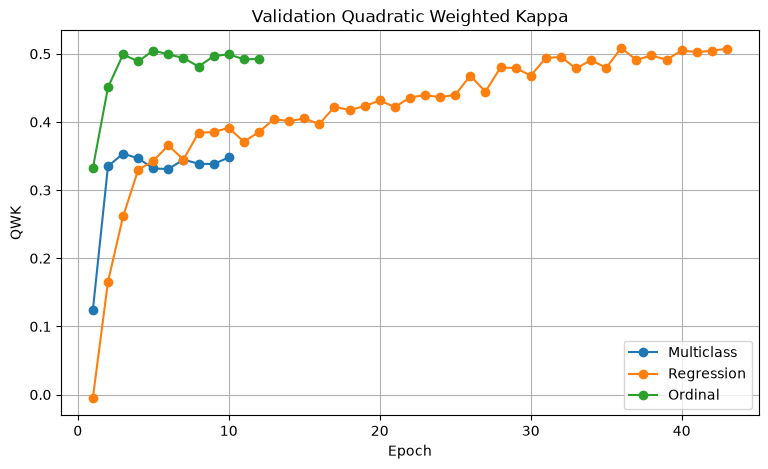

In [39]:
plt.figure(figsize=(9, 5))

for model_name, history_df in (
    training_histories.items()
):
    plt.plot(
        history_df["epoch"],
        history_df[
            "validation_qwk"
        ],
        marker="o",
        label=model_name
    )

plt.title(
    "Validation Quadratic Weighted Kappa"
)

plt.xlabel("Epoch")
plt.ylabel("QWK")
plt.legend()
plt.grid(True)
plt.show()

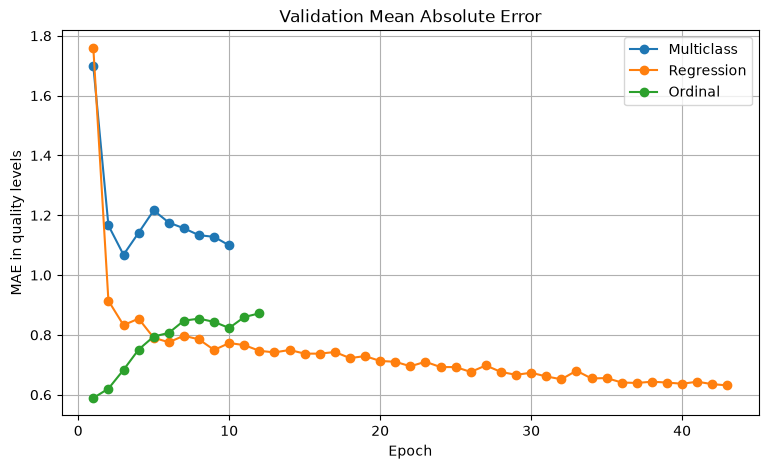

In [40]:
plt.figure(figsize=(9, 5))

for model_name, history_df in (
    training_histories.items()
):
    plt.plot(
        history_df["epoch"],
        history_df[
            "validation_mae"
        ],
        marker="o",
        label=model_name
    )

plt.title(
    "Validation Mean Absolute Error"
)

plt.xlabel("Epoch")
plt.ylabel("MAE in quality levels")
plt.legend()
plt.grid(True)
plt.show()

## Training behaviour 

The three models showed very different optimisation patterns.

### Multiclass model

The multiclass model achieved its best validation result at Epoch 3:

- Validation QWK: 0.3535
- Validation MAE: 1.0680
- Validation accuracy: 0.2816

Training continued until early stopping at Epoch 10, but later epochs did not exceed the Epoch 3 QWK.

The multiclass model converged quickly but remained substantially weaker than the order-aware formulations.

### Regression model

Regression improved gradually over a much longer training period.

Its best validation QWK occurred at Epoch 36:

- Validation QWK: 0.5085
- Validation MAE: 0.6408
- Validation accuracy: 0.4531

The lowest validation MAE occurred later, at Epoch 43:

- MAE: 0.6313
- QWK: 0.5074

Early stopping was triggered at Epoch 43, and the Epoch 36 checkpoint was restored because QWK was the primary selection metric.

### Ordinal model

The ordinal model learned useful ordering very quickly.

Its best validation QWK occurred at Epoch 5:

- Validation QWK: 0.5049
- Validation MAE: 0.7946
- Validation accuracy: 0.3687

Early stopping was triggered at Epoch 12.

Interestingly, the ordinal model’s lowest validation MAE occurred at Epoch 1:

- MAE: 0.5891
- QWK: 0.3324

As training continued, QWK improved while MAE worsened. The class-balanced threshold loss encouraged better separation across the full scale, but it also moved more predictions away from the common middle classes.

Overall:

- Multiclass reached its own best checkpoint fastest, at Epoch 3
- Ordinal reached strong ordering performance by Epoch 5
- Regression required 36 epochs but achieved the best validation QWK

In [41]:
multiclass_test_result = (
    evaluate_quality_model(
        multiclass_model,
        test_loader,
        "Multiclass"
    )
)

regression_test_result = (
    evaluate_quality_model(
        regression_model,
        test_loader,
        "Regression"
    )
)

ordinal_test_result = (
    evaluate_quality_model(
        ordinal_model,
        test_loader,
        "Ordinal"
    )
)

In [42]:
model_test_results = {
    "Constant baseline": {
        "metrics": baseline_metrics,
        "true_ranks":
            y_test.to_numpy(),
        "predicted_ranks":
            baseline_predictions,
        "ordering_scores":
            baseline_predictions.astype(
                float
            )
    },

    "Multiclass":
        multiclass_test_result,

    "Regression":
        regression_test_result,

    "Ordinal":
        ordinal_test_result
}

In [43]:
comparison_rows = []

for model_name, result in (
    model_test_results.items()
):
    comparison_rows.append({
        "model": model_name,
        **result["metrics"]
    })

model_comparison_df = (
    pd.DataFrame(
        comparison_rows
    )
    .sort_values(
        [
            "quadratic_weighted_kappa",
            "mean_absolute_error"
        ],
        ascending=[
            False,
            True
        ]
    )
    .reset_index(drop=True)
)

model_comparison_df

,model,accuracy,balanced_accuracy,mean_absolute_error,within_one_accuracy,severe_error_rate,quadratic_weighted_kappa,loss
0,Regression,0.446259,0.251962,0.632653,0.927891,0.072109,0.530522,0.759405
1,Ordinal,0.387755,0.290931,0.804082,0.834014,0.165986,0.484433,0.405788
2,Multiclass,0.303401,0.269042,1.061224,0.708844,0.291156,0.339128,1.735777
3,Constant baseline,0.448980,0.142857,0.629932,0.926531,0.073469,0.000000,NaN


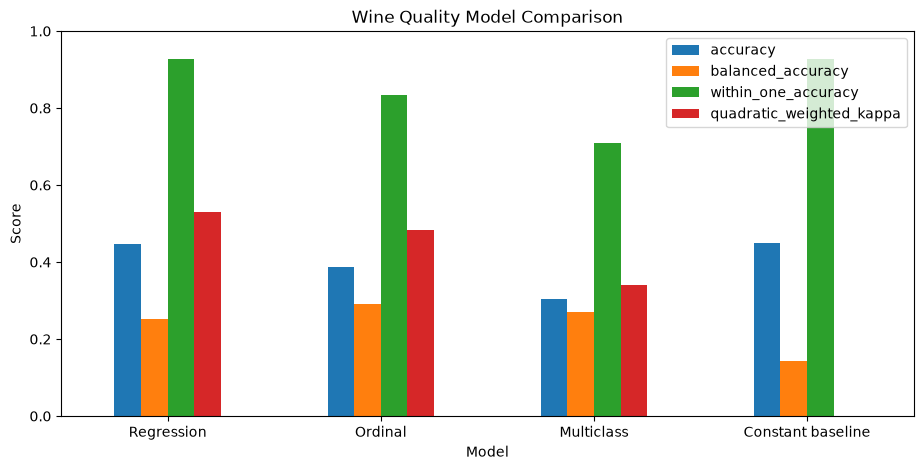

In [44]:
model_comparison_df.set_index(
    "model"
)[
    [
        "accuracy",
        "balanced_accuracy",
        "within_one_accuracy",
        "quadratic_weighted_kappa"
    ]
].plot(
    kind="bar",
    figsize=(11, 5)
)

plt.title(
    "Wine Quality Model Comparison"
)

plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

## Final model comparison 

Final test performance was:

| Model | Accuracy | Balanced accuracy | MAE | Within one | Severe errors | QWK |
|---|---:|---:|---:|---:|---:|---:|
| Constant baseline | 0.4490 | 0.1429 | 0.6299 | 0.9265 | 0.0735 | 0.0000 |
| Multiclass | 0.3034 | 0.2690 | 1.0612 | 0.7088 | 0.2912 | 0.3391 |
| Regression | 0.4463 | 0.2520 | 0.6327 | 0.9279 | 0.0721 | 0.5305 |
| Ordinal | 0.3878 | 0.2909 | 0.8041 | 0.8340 | 0.1660 | 0.4844 |

No single model was strongest on every metric.

### Exact accuracy and MAE

The constant baseline had:

- the highest exact accuracy: 0.4490
- the lowest MAE: 0.6299

However, its advantage over Regression was tiny:

- Accuracy difference: approximately 0.0027
- MAE difference: approximately 0.0027

These metrics rewarded the baseline for always predicting the dominant middle quality.

### Ordering-aware performance

Regression achieved:

- highest QWK: 0.5305
- highest pairwise ordering accuracy
- highest within-one accuracy
- lowest severe-error rate
- best exact accuracy among neural models

It therefore produced the most useful overall ordering despite not beating the constant baseline on raw accuracy.

### Ordinal model

The ordinal model achieved the highest balanced accuracy:

`0.2909`

It also clearly outperformed multiclass classification on:

- exact accuracy
- MAE
- within-one accuracy
- severe-error rate
- QWK
- pairwise ordering

The ordinal formulation was therefore more sensible than treating quality levels as unrelated classes, but it did not outperform continuous regression.

### Multiclass model

Multiclass classification produced the weakest neural result and a severe-error rate of 29.12%.

Treating distant and neighbouring mistakes as equivalent was poorly matched to this ordered target.

In [45]:
def calculate_pairwise_ordering_accuracy(
    true_ranks,
    ordering_scores,
    number_of_pairs=30_000,
    seed=42
):
    true_ranks = np.asarray(
        true_ranks
    )

    ordering_scores = np.asarray(
        ordering_scores
    )

    rng = np.random.default_rng(
        seed
    )

    valid_comparisons = 0
    correct_comparisons = 0
    tied_predictions = 0

    maximum_attempts = (
        number_of_pairs * 10
    )

    attempts = 0

    while (
        valid_comparisons
        < number_of_pairs
        and attempts < maximum_attempts
    ):
        first_index = int(
            rng.integers(
                0,
                len(true_ranks)
            )
        )

        second_index = int(
            rng.integers(
                0,
                len(true_ranks)
            )
        )

        attempts += 1

        if (
            first_index == second_index
            or true_ranks[first_index]
            == true_ranks[second_index]
        ):
            continue

        true_direction = np.sign(
            true_ranks[first_index]
            - true_ranks[second_index]
        )

        predicted_direction = np.sign(
            ordering_scores[first_index]
            - ordering_scores[
                second_index
            ]
        )

        if predicted_direction == 0:
            tied_predictions += 1

        elif (
            predicted_direction
            == true_direction
        ):
            correct_comparisons += 1

        valid_comparisons += 1

    return {
        "pairwise_ordering_accuracy":
            correct_comparisons
            / valid_comparisons,

        "prediction_tie_rate":
            tied_predictions
            / valid_comparisons,

        "evaluated_pairs":
            valid_comparisons
    }

In [46]:
pairwise_rows = []

for model_name, result in (
    model_test_results.items()
):
    pairwise_metrics = (
        calculate_pairwise_ordering_accuracy(
            result["true_ranks"],
            result["ordering_scores"],
            number_of_pairs=30_000,
            seed=RANDOM_STATE
        )
    )

    pairwise_rows.append({
        "model": model_name,
        **pairwise_metrics
    })

pairwise_comparison_df = (
    pd.DataFrame(pairwise_rows)
    .sort_values(
        "pairwise_ordering_accuracy",
        ascending=False
    )
)

pairwise_comparison_df

,model,pairwise_ordering_accuracy,prediction_tie_rate,evaluated_pairs
2,Regression,0.769433,0.0,30000
3,Ordinal,0.755367,0.0,30000
1,Multiclass,0.733100,0.0,30000
0,Constant baseline,0.000000,1.0,30000


## Pairwise ranking 

Pairwise ordering results were:

| Model | Pairwise ordering accuracy | Prediction tie rate |
|---|---:|---:|
| Regression | 0.7694 | 0.0000 |
| Ordinal | 0.7554 | 0.0000 |
| Multiclass | 0.7331 | 0.0000 |
| Constant baseline | 0.0000 | 1.0000 |

Regression correctly ranked the higher-quality wine above the lower-quality wine in approximately 76.94% of the 30,000 evaluated pairs.

The ordinal model followed closely at 75.54%.

The multiclass model still contained some ordering information because its expected-rank score was calculated from class probabilities, but it was less reliable.

The constant baseline gave every wine the same score. All comparisons were ties, so it had zero pairwise ranking accuracy despite its relatively high exact classification accuracy.

In [47]:
best_model_name = (
    model_comparison_df.iloc[0][
        "model"
    ]
)

best_test_result = (
    model_test_results[
        best_model_name
    ]
)

best_prediction_df = pd.DataFrame({
    "true_rank":
        best_test_result[
            "true_ranks"
        ],

    "predicted_rank":
        best_test_result[
            "predicted_ranks"
        ]
})

best_prediction_df["true_quality"] = (
    ranks_to_qualities(
        best_prediction_df[
            "true_rank"
        ]
    )
)

best_prediction_df[
    "predicted_quality"
] = ranks_to_qualities(
    best_prediction_df[
        "predicted_rank"
    ]
)

best_prediction_df[
    "absolute_error"
] = np.abs(
    best_prediction_df[
        "predicted_quality"
    ]
    - best_prediction_df[
        "true_quality"
    ]
)

In [48]:
quality_performance_df = (
    best_prediction_df
    .groupby("true_quality")
    .agg(
        observations=(
            "true_quality",
            "size"
        ),

        exact_accuracy=(
            "absolute_error",
            lambda values:
                np.mean(values == 0)
        ),

        within_one_accuracy=(
            "absolute_error",
            lambda values:
                np.mean(values <= 1)
        ),

        mean_absolute_error=(
            "absolute_error",
            "mean"
        ),

        severe_error_rate=(
            "absolute_error",
            lambda values:
                np.mean(values >= 2)
        )
    )
    .reset_index()
)

quality_performance_df

,true_quality,observations,exact_accuracy,within_one_accuracy,mean_absolute_error,severe_error_rate
0,3,3,0.000000,0.333333,2.333333,0.666667
1,4,24,0.291667,0.791667,0.958333,0.208333
2,5,219,0.598174,0.940639,0.461187,0.059361
3,6,330,0.418182,0.942424,0.642424,0.057576
4,7,132,0.378788,0.954545,0.674242,0.045455
5,8,26,0.076923,0.692308,1.230769,0.307692
6,9,1,0.000000,1.000000,1.000000,0.000000


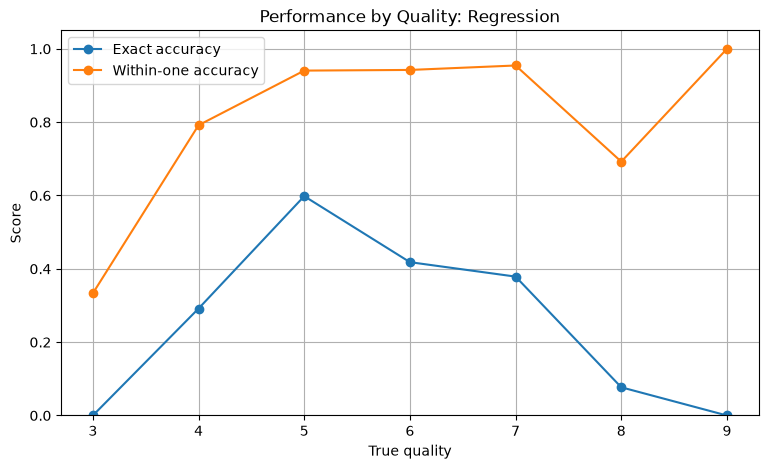

In [49]:
plt.figure(figsize=(9, 5))

plt.plot(
    quality_performance_df[
        "true_quality"
    ],
    quality_performance_df[
        "exact_accuracy"
    ],
    marker="o",
    label="Exact accuracy"
)

plt.plot(
    quality_performance_df[
        "true_quality"
    ],
    quality_performance_df[
        "within_one_accuracy"
    ],
    marker="o",
    label="Within-one accuracy"
)

plt.title(
    f"Performance by Quality: "
    f"{best_model_name}"
)

plt.xlabel("True quality")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)
plt.show()

## Quality level performance 

The following analysis used Regression because it achieved the highest test QWK.

| True quality | Test wines | Exact accuracy | Within one | MAE | Severe errors |
|---:|---:|---:|---:|---:|---:|
| 3 | 3 | 0.0000 | 0.3333 | 2.3333 | 0.6667 |
| 4 | 24 | 0.2917 | 0.7917 | 0.9583 | 0.2083 |
| 5 | 219 | 0.5982 | 0.9406 | 0.4612 | 0.0594 |
| 6 | 330 | 0.4182 | 0.9424 | 0.6424 | 0.0576 |
| 7 | 132 | 0.3788 | 0.9545 | 0.6742 | 0.0455 |
| 8 | 26 | 0.0769 | 0.6923 | 1.2308 | 0.3077 |
| 9 | 1 | 0.0000 | 1.0000 | 1.0000 | 0.0000 |

Quality 5 was the easiest level, with exact accuracy of 59.82%.

Quality 3 had the largest MAE and severe-error rate, but it contained only three test examples. Quality 9 contained only one test example, which was predicted as quality 8.

Performance was strongest for the common middle qualities and much weaker for the rare extremes.

The model showed regression toward the centre:

- low-quality wines were often predicted too high
- quality-8 and quality-9 wines were usually predicted too low
- neighbouring middle qualities were frequently confused

Within-one accuracy remained high for qualities 5, 6, and 7, showing that most central-class mistakes still preserved approximate ordering.

In [50]:
error_distance_rows = []

for model_name, result in (
    model_test_results.items()
):
    true_quality = ranks_to_qualities(
        result["true_ranks"]
    )

    predicted_quality = (
        ranks_to_qualities(
            result[
                "predicted_ranks"
            ]
        )
    )

    absolute_errors = np.abs(
        predicted_quality
        - true_quality
    )

    for error_distance in sorted(
        np.unique(absolute_errors)
    ):
        error_distance_rows.append({
            "model": model_name,
            "error_distance":
                int(error_distance),
            "observations":
                int(
                    np.sum(
                        absolute_errors
                        == error_distance
                    )
                ),
            "percentage":
                np.mean(
                    absolute_errors
                    == error_distance
                )
        })

error_distance_df = pd.DataFrame(
    error_distance_rows
)

error_distance_df

,model,error_distance,observations,percentage
0,Constant baseline,0,330,0.448980
1,Constant baseline,1,351,0.477551
2,Constant baseline,2,50,0.068027
3,Constant baseline,3,4,0.005442
4,Multiclass,0,223,0.303401
5,Multiclass,1,298,0.405442
6,Multiclass,2,169,0.229932
7,Multiclass,3,37,0.050340
8,Multiclass,4,7,0.009524
9,Multiclass,5,1,0.001361


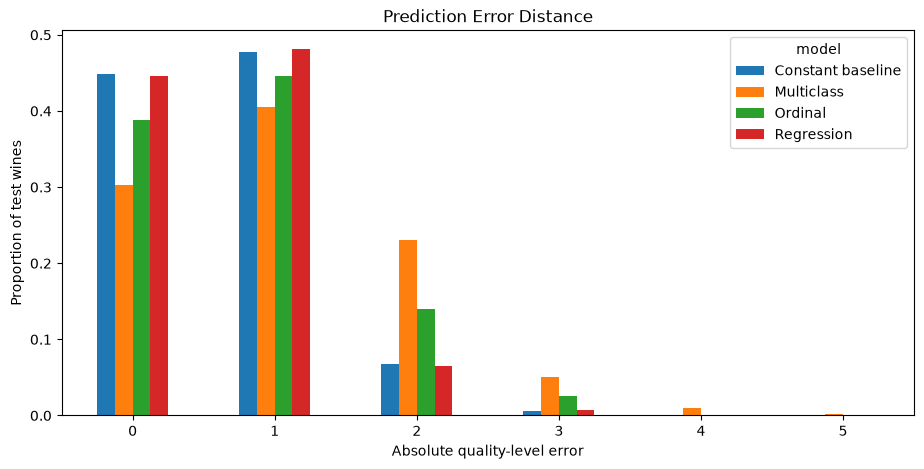

In [51]:
error_distance_pivot = (
    error_distance_df
    .pivot(
        index="error_distance",
        columns="model",
        values="percentage"
    )
    .fillna(0)
)

error_distance_pivot.plot(
    kind="bar",
    figsize=(11, 5)
)

plt.title(
    "Prediction Error Distance"
)

plt.xlabel(
    "Absolute quality-level error"
)

plt.ylabel("Proportion of test wines")
plt.xticks(rotation=0)
plt.show()

## Error distance 

The prediction-distance distributions were:

| Model | Exact | One-level error | Error of two or more |
|---|---:|---:|---:|
| Constant baseline | 44.90% | 47.76% | 7.35% |
| Multiclass | 30.34% | 40.54% | 29.12% |
| Regression | 44.63% | 48.16% | 7.21% |
| Ordinal | 38.78% | 44.63% | 16.60% |

Regression produced:

- 328 exact predictions
- 354 one-level errors
- 53 severe errors

Its exact accuracy was slightly below the constant baseline, but it had:

- more one-level predictions
- fewer severe errors
- meaningful ordering between observations

The ordinal model greatly reduced distant mistakes compared with multiclass classification, but it still produced more severe errors than Regression.

Multiclass classification generated the widest error distribution, including:

- 169 two-level errors
- 37 three-level errors
- 7 four-level errors
- 1 five-level error

This supports the idea that ordinary cross-entropy did not adequately account for error distance.

In [52]:
def plot_quality_confusion_matrix(
    true_ranks,
    predicted_ranks,
    model_name
):
    matrix = confusion_matrix(
        true_ranks,
        predicted_ranks,
        labels=np.arange(
            NUMBER_OF_QUALITY_LEVELS
        ),
        normalize="true"
    )

    plt.figure(figsize=(7, 6))

    plt.imshow(
        matrix,
        vmin=0,
        vmax=1
    )

    plt.colorbar(
        label="Row-normalised proportion"
    )

    plt.xticks(
        range(
            NUMBER_OF_QUALITY_LEVELS
        ),
        quality_values
    )

    plt.yticks(
        range(
            NUMBER_OF_QUALITY_LEVELS
        ),
        quality_values
    )

    plt.xlabel("Predicted quality")
    plt.ylabel("True quality")

    plt.title(
        f"Normalised Confusion Matrix: "
        f"{model_name}"
    )

    for row_index in range(
        NUMBER_OF_QUALITY_LEVELS
    ):
        for column_index in range(
            NUMBER_OF_QUALITY_LEVELS
        ):
            value = matrix[
                row_index,
                column_index
            ]

            if value >= 0.01:
                plt.text(
                    column_index,
                    row_index,
                    f"{value:.2f}",
                    ha="center",
                    va="center"
                )

    plt.show()

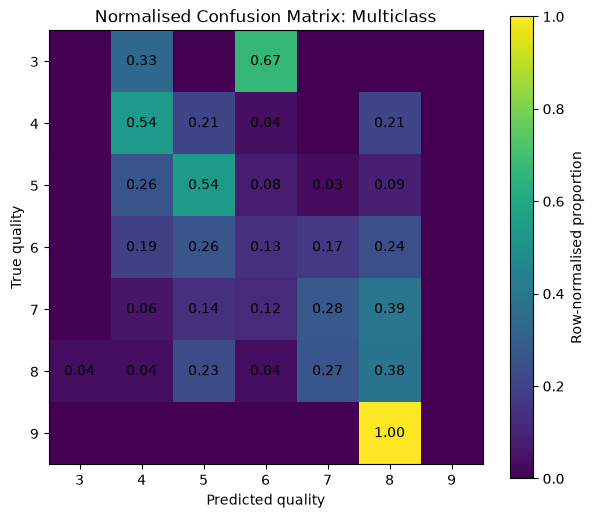

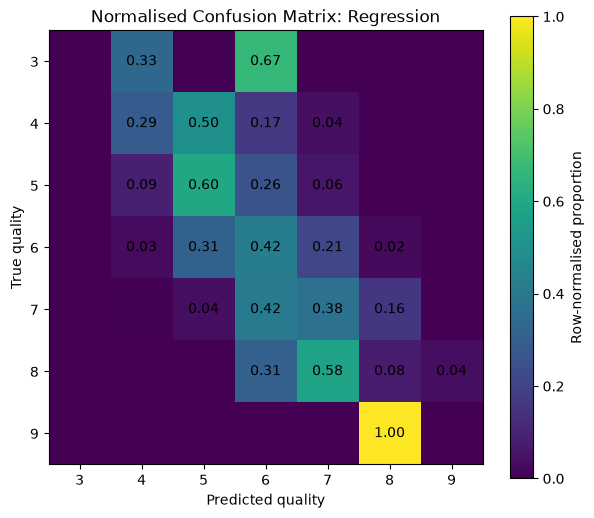

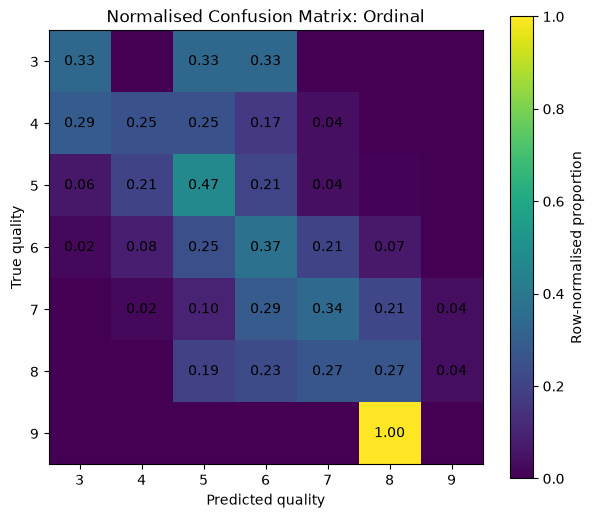

In [53]:
for model_name in [
    "Multiclass",
    "Regression",
    "Ordinal"
]:
    plot_quality_confusion_matrix(
        model_test_results[
            model_name
        ]["true_ranks"],

        model_test_results[
            model_name
        ]["predicted_ranks"],

        model_name
    )

## Confusion matrix 

### Multiclass model

The multiclass predictions were widely dispersed.

Examples included:

- True quality 3 was predicted as quality 4 or 6
- True quality 6 was spread across qualities 4 through 8
- True quality 9 was predicted as quality 8
- Several classes were predicted multiple levels away from the diagonal

This model produced the broadest confusion pattern and the highest severe-error rate.

### Regression model

Regression produced the narrowest diagonal band.

Most predictions fell:

- on the correct quality
- one level below
- one level above

Quality 5 was most often predicted correctly, while qualities 6 and 7 were frequently confused with each other and their neighbouring levels.

The extreme classes were pulled toward the centre:

- quality 3 was predicted as 4 or 6
- quality 8 was mainly predicted as 6 or 7
- the single quality-9 wine was predicted as 8

### Ordinal model

The ordinal model produced a more orderly confusion pattern than multiclass classification, but its predictions were more spread out than Regression.

It handled middle qualities reasonably but distributed quality-8 examples across qualities 5 through 9.

No model reliably learned the rare extremes because only a handful of examples were available.

In [54]:
ordinal_model.eval()

with torch.no_grad():
    learned_cutpoints = (
        ordinal_model
        .ordered_cutpoints()
        .cpu()
        .numpy()
    )

threshold_df = pd.DataFrame({
    "boundary": [
        (
            f"{quality_values[index]} "
            f"vs {quality_values[index + 1]}+"
        )
        for index in range(
            NUMBER_OF_THRESHOLDS
        )
    ],
    "latent_cutpoint":
        learned_cutpoints
})

threshold_df

,boundary,latent_cutpoint
0,3 vs 4+,-1.515589
1,4 vs 5+,-0.949142
2,5 vs 6+,-0.374935
3,6 vs 7+,0.205703
4,7 vs 8+,0.792362
5,8 vs 9+,1.384423


In [55]:
ordinal_scores = (
    ordinal_test_result[
        "ordering_scores"
    ]
)

ordinal_score_df = pd.DataFrame({
    "true_quality":
        ranks_to_qualities(
            ordinal_test_result[
                "true_ranks"
            ]
        ),
    "latent_quality_score":
        ordinal_scores
})

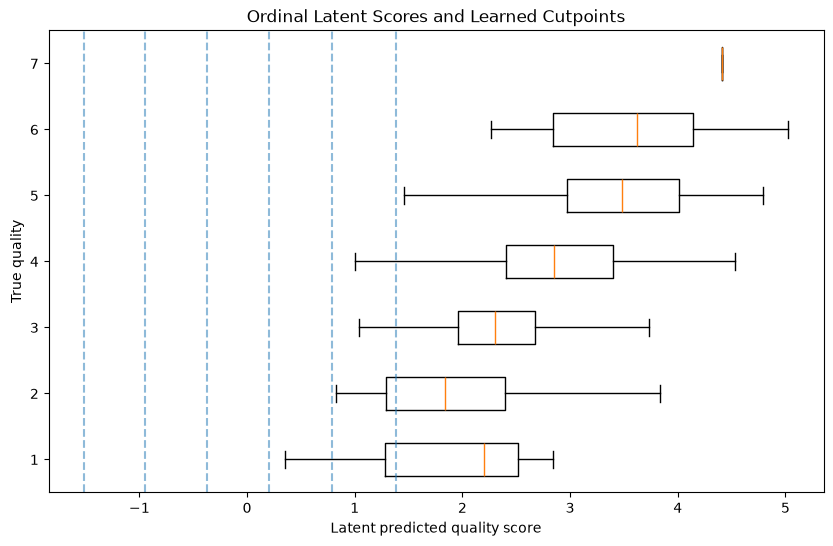

In [58]:
quality_score_groups = [
    ordinal_score_df.loc[
        ordinal_score_df[
            "true_quality"
        ] == quality,
        "latent_quality_score"
    ].to_numpy()

    for quality in quality_values
]

plt.figure(figsize=(10, 6))

plt.boxplot(
    quality_score_groups,
    vert=False,
    showfliers=False
)

for cutpoint in learned_cutpoints:
    plt.axvline(
        cutpoint,
        linestyle="--",
        alpha=0.5
    )

plt.title(
    "Ordinal Latent Scores and Learned Cutpoints"
)

plt.xlabel("Latent predicted quality score")
plt.ylabel("True quality")
plt.show()

## Learned ordinal representation 

The model learned the following ordered cutpoints:

| Boundary | Cutpoint |
|---|---:|
| 3 vs 4+ | -1.5156 |
| 4 vs 5+ | -0.9491 |
| 5 vs 6+ | -0.3749 |
| 6 vs 7+ | 0.2057 |
| 7 vs 8+ | 0.7924 |
| 8 vs 9+ | 1.3844 |

The cutpoints remained strictly ordered, as required by the model design.

Their gaps were also relatively even and increased slightly across the scale.

### Important plotting issue

The boxplot labelled as a latent-score plot does not currently contain the model’s raw latent scores.

It uses:

`ordinal_test_result["ordering_scores"]`

For the ordinal decoder, this value is the sum of the six threshold probabilities and lies approximately between 0 and 6.

The dashed cutpoints, however, are expressed on the raw latent-score scale. Therefore, their horizontal positions cannot be validly compared with the displayed boxplots.

The ordering-score distributions still generally increased with true quality, but they overlapped substantially across neighbouring classes. This overlap reflects the difficulty of separating sensory ratings using only physicochemical measurements.

A corrected plot should calculate scores using:

`ordinal_model.latent_score(features)`

before displaying the learned cutpoints.

In [59]:
@torch.no_grad()
def get_ordinal_probabilities(
    model,
    feature_array
):
    model.eval()

    feature_tensor = torch.tensor(
        feature_array,
        dtype=torch.float32,
        device=device
    )

    logits = model(feature_tensor)

    return (
        torch.sigmoid(logits)
        .cpu()
        .numpy()
    )

In [60]:
inspection_indices = (
    pd.Series(
        y_test.to_numpy()
    )
    .sort_values()
    .index
    .to_numpy()
)

selected_indices = np.linspace(
    0,
    len(inspection_indices) - 1,
    num=10,
    dtype=int
)

selected_indices = (
    inspection_indices[
        selected_indices
    ]
)

selected_probabilities = (
    get_ordinal_probabilities(
        ordinal_model,
        X_test_scaled[
            selected_indices
        ]
    )
)

In [61]:
probability_table = pd.DataFrame(
    selected_probabilities,
    columns=[
        f"P(quality > {quality})"
        for quality in
        quality_values[:-1]
    ]
)

probability_table.insert(
    0,
    "true_quality",
    ranks_to_qualities(
        y_test.to_numpy()[
            selected_indices
        ]
    )
)

probability_table.insert(
    1,
    "predicted_quality",
    ranks_to_qualities(
        ordinal_test_result[
            "predicted_ranks"
        ][selected_indices]
    )
)

probability_table

,true_quality,predicted_quality,P(quality > 3),P(quality > 4),P(quality > 5),P(quality > 6),P(quality > 7),P(quality > 8)
0,3,6,0.786868,0.676930,0.541279,0.397679,0.268587,0.168841
1,5,5,0.687830,0.555656,0.413223,0.282662,0.179763,0.108127
2,5,5,0.755673,0.637067,0.497113,0.356133,0.235260,0.145429
3,5,4,0.636578,0.498524,0.358907,0.238531,0.148374,0.087907
4,6,7,0.883370,0.811271,0.707668,0.575285,0.429666,0.294158
5,6,6,0.834571,0.741146,0.617211,0.474295,0.334128,0.217272
6,6,6,0.774221,0.660574,0.522896,0.380131,0.254330,0.158729
7,6,6,0.790359,0.681494,0.546475,0.402707,0.272721,0.171800
8,7,7,0.865393,0.784887,0.672644,0.534826,0.390044,0.261306
9,9,8,0.935811,0.892173,0.823308,0.722778,0.591852,0.445113


## Threshold probability 

The selected ordinal predictions had monotonically decreasing cumulative probabilities.

For every observation:

`P(quality > 3) ≥ P(quality > 4) ≥ ... ≥ P(quality > 8)`

This ordering was guaranteed by using one latent score with ordered cutpoints.

For example, one true quality-3 wine was predicted as quality 6 because:

- `P(quality > 3) = 0.7869`
- `P(quality > 4) = 0.6769`
- `P(quality > 5) = 0.5413`
- `P(quality > 6) = 0.3977`

The first three thresholds exceeded 0.5, producing rank 3, which corresponded to quality 6.

The true quality-9 example was predicted as quality 8 because:

- probabilities exceeded 0.5 through `P(quality > 7)`
- `P(quality > 8) = 0.4451`

The model therefore stopped one boundary below the maximum quality.

This cumulative representation preserves ordering more naturally than independent multiclass probabilities.

In [62]:
@torch.no_grad()
def predict_from_array(
    model,
    model_type,
    feature_array
):
    model.eval()

    feature_tensor = torch.tensor(
        feature_array,
        dtype=torch.float32,
        device=device
    )

    batch_predictions = []
    batch_scores = []

    for start in range(
        0,
        len(feature_tensor),
        512
    ):
        batch_features = (
            feature_tensor[
                start:start + 512
            ]
        )

        outputs = model(
            batch_features
        )

        (
            predicted_ranks,
            ordering_scores
        ) = decode_outputs(
            outputs,
            model_type
        )

        batch_predictions.extend(
            predicted_ranks
            .cpu()
            .numpy()
        )

        batch_scores.extend(
            ordering_scores
            .cpu()
            .numpy()
        )

    return (
        np.asarray(
            batch_predictions
        ),
        np.asarray(
            batch_scores
        )
    )

In [63]:
neural_comparison_df = (
    model_comparison_df[
        model_comparison_df[
            "model"
        ].isin([
            "Multiclass",
            "Regression",
            "Ordinal"
        ])
    ]
)

importance_model_name = (
    neural_comparison_df
    .iloc[0]["model"]
)

importance_model_lookup = {
    "Multiclass":
        multiclass_model,
    "Regression":
        regression_model,
    "Ordinal":
        ordinal_model
}

importance_model = (
    importance_model_lookup[
        importance_model_name
    ]
)

print(
    "Permutation-importance model:",
    importance_model_name
)

Permutation-importance model: Regression


In [64]:
baseline_importance_predictions, _ = (
    predict_from_array(
        importance_model,
        importance_model_name,
        X_test_scaled
    )
)

baseline_importance_qwk = (
    cohen_kappa_score(
        y_test.to_numpy(),
        baseline_importance_predictions,
        weights="quadratic"
    )
)

In [65]:
importance_rng = np.random.default_rng(
    RANDOM_STATE
)

PERMUTATION_REPETITIONS = 15

importance_rows = []

for feature_index, feature_name in enumerate(
    feature_columns
):
    qwk_drops = []

    for repetition in range(
        PERMUTATION_REPETITIONS
    ):
        permuted_features = (
            X_test_scaled.copy()
        )

        permuted_features[
            :,
            feature_index
        ] = importance_rng.permutation(
            permuted_features[
                :,
                feature_index
            ]
        )

        permuted_predictions, _ = (
            predict_from_array(
                importance_model,
                importance_model_name,
                permuted_features
            )
        )

        permuted_qwk = (
            cohen_kappa_score(
                y_test.to_numpy(),
                permuted_predictions,
                weights="quadratic"
            )
        )

        qwk_drops.append(
            baseline_importance_qwk
            - permuted_qwk
        )

    importance_rows.append({
        "feature": feature_name,
        "mean_qwk_drop":
            np.mean(qwk_drops),
        "std_qwk_drop":
            np.std(qwk_drops)
    })

permutation_importance_df = (
    pd.DataFrame(
        importance_rows
    )
    .sort_values(
        "mean_qwk_drop",
        ascending=False
    )
    .reset_index(drop=True)
)

permutation_importance_df

,feature,mean_qwk_drop,std_qwk_drop
0,density,0.204012,0.023339
1,alcohol,0.167636,0.012252
2,volatile_acidity,0.123376,0.012332
3,residual_sugar,0.083623,0.015190
4,ph,0.055057,0.008750
5,chlorides,0.041316,0.010435
6,sulphates,0.021820,0.007129
7,free_sulfur_dioxide,0.021147,0.010542
8,fixed_acidity,0.020296,0.008469
9,total_sulfur_dioxide,0.016784,0.009860


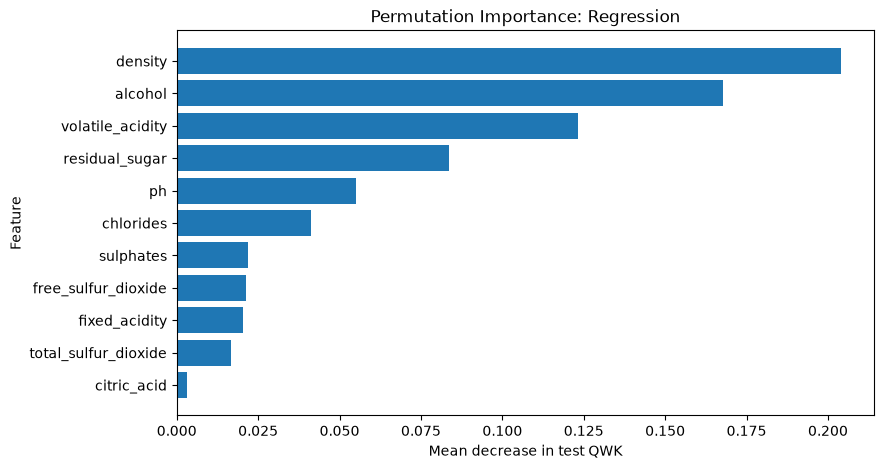

In [66]:
plt.figure(figsize=(9, 5))

plt.barh(
    permutation_importance_df[
        "feature"
    ][::-1],
    permutation_importance_df[
        "mean_qwk_drop"
    ][::-1]
)

plt.title(
    f"Permutation Importance: "
    f"{importance_model_name}"
)

plt.xlabel(
    "Mean decrease in test QWK"
)

plt.ylabel("Feature")
plt.show()

## Feature importance 

Permutation importance was calculated using the Regression model because it had the highest neural-model test QWK.

Results were:

| Feature | Mean QWK decrease |
|---|---:|
| Density | 0.2040 |
| Alcohol | 0.1676 |
| Volatile acidity | 0.1234 |
| Residual sugar | 0.0836 |
| pH | 0.0551 |
| Chlorides | 0.0413 |
| Sulphates | 0.0218 |
| Free sulfur dioxide | 0.0211 |
| Fixed acidity | 0.0203 |
| Total sulfur dioxide | 0.0168 |
| Citric acid | 0.0033 |

Density was the most influential feature. Shuffling it reduced QWK by approximately 0.204.

Alcohol was the second-most influential feature, followed by volatile acidity.

Citric acid had almost no effect on test QWK under this fitted model.

No feature produced a meaningful negative importance value, so none of the tested permutations consistently improved performance.

Density, alcohol, and residual sugar are also related physicochemically, so permutation importance should not be interpreted as an independent causal effect. Correlated features can share or redistribute importance.

In [67]:
noise_levels = [
    0.00,
    0.25,
    0.50,
    1.00
]

noise_repetitions = 10

robustness_rows = []

robustness_models = {
    "Multiclass":
        multiclass_model,
    "Regression":
        regression_model,
    "Ordinal":
        ordinal_model
}

In [68]:
for model_name, model in (
    robustness_models.items()
):
    for noise_standard_deviation in (
        noise_levels
    ):
        repetition_metrics = []

        for repetition in range(
            noise_repetitions
        ):
            noise_rng = (
                np.random.default_rng(
                    RANDOM_STATE
                    + repetition
                    + int(
                        noise_standard_deviation
                        * 1_000
                    )
                )
            )

            noisy_features = (
                X_test_scaled
                + noise_rng.normal(
                    loc=0.0,
                    scale=
                        noise_standard_deviation,
                    size=
                        X_test_scaled.shape
                )
            )

            noisy_predictions, _ = (
                predict_from_array(
                    model,
                    model_name,
                    noisy_features
                )
            )

            noisy_metrics = (
                calculate_ordinal_metrics(
                    y_test.to_numpy(),
                    noisy_predictions
                )
            )

            repetition_metrics.append(
                noisy_metrics
            )

        robustness_rows.append({
            "model": model_name,
            "noise_standard_deviation":
                noise_standard_deviation,

            "mean_accuracy":
                np.mean([
                    result["accuracy"]
                    for result
                    in repetition_metrics
                ]),

            "mean_mae":
                np.mean([
                    result[
                        "mean_absolute_error"
                    ]
                    for result
                    in repetition_metrics
                ]),

            "mean_qwk":
                np.mean([
                    result[
                        "quadratic_weighted_kappa"
                    ]
                    for result
                    in repetition_metrics
                ]),

            "mean_severe_error_rate":
                np.mean([
                    result[
                        "severe_error_rate"
                    ]
                    for result
                    in repetition_metrics
                ])
        })

robustness_df = pd.DataFrame(
    robustness_rows
)

robustness_df

,model,noise_standard_deviation,mean_accuracy,mean_mae,mean_qwk,mean_severe_error_rate
0,Multiclass,0.00,0.303401,1.061224,0.339128,0.291156
1,Multiclass,0.25,0.298912,1.065170,0.335630,0.292789
2,Multiclass,0.50,0.300000,1.060544,0.325057,0.289660
3,Multiclass,1.00,0.293197,1.090476,0.239218,0.296599
4,Regression,0.00,0.446259,0.632653,0.530522,0.072109
5,Regression,0.25,0.436599,0.663537,0.505260,0.089932
6,Regression,0.50,0.380952,0.783129,0.429074,0.140136
7,Regression,1.00,0.272109,1.129660,0.243498,0.297551
8,Ordinal,0.00,0.387755,0.804082,0.484433,0.165986
9,Ordinal,0.25,0.370612,0.831837,0.468482,0.172381


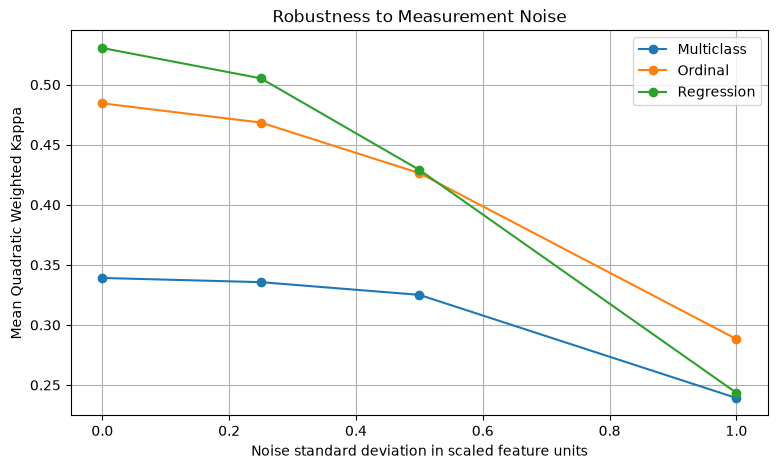

In [69]:
plt.figure(figsize=(9, 5))

for model_name, group_df in (
    robustness_df.groupby("model")
):
    plt.plot(
        group_df[
            "noise_standard_deviation"
        ],
        group_df["mean_qwk"],
        marker="o",
        label=model_name
    )

plt.title(
    "Robustness to Measurement Noise"
)

plt.xlabel(
    "Noise standard deviation "
    "in scaled feature units"
)

plt.ylabel("Mean Quadratic Weighted Kappa")
plt.legend()
plt.grid(True)
plt.show()

## Noise robustness 

Mean QWK under added measurement noise was:

| Noise standard deviation | Multiclass | Regression | Ordinal |
|---:|---:|---:|---:|
| 0.00 | 0.3391 | 0.5305 | 0.4844 |
| 0.25 | 0.3356 | 0.5053 | 0.4685 |
| 0.50 | 0.3251 | 0.4291 | 0.4264 |
| 1.00 | 0.2392 | 0.2435 | 0.2883 |

Regression remained the strongest model under no, low, and moderate additional noise.

At noise level 0.50, Regression and Ordinal became almost equal:

- Regression QWK: 0.4291
- Ordinal QWK: 0.4264

At the highest noise level, Ordinal achieved the best QWK:

`0.2883`

This suggests that its ordered-threshold representation retained ranking information slightly better under extreme measurement corruption.

However, severe-error rates at noise level 1.00 were:

- Multiclass: 0.2966
- Regression: 0.2976
- Ordinal: 0.3448

Therefore, Ordinal had the best high-noise QWK but also the highest severe-error rate.

Regression’s QWK declined more than Ordinal’s, but it began from a substantially stronger clean result. The most suitable model therefore depends on whether clean performance, ranking robustness, or severe-error control is prioritised.

In [70]:
severe_error_indices = (
    best_prediction_df[
        best_prediction_df[
            "absolute_error"
        ] >= 2
    ]
    .sort_values(
        "absolute_error",
        ascending=False
    )
    .index
)

severe_error_examples_df = (
    X_test
    .reset_index(drop=True)
    .iloc[severe_error_indices]
    .copy()
)

severe_error_examples_df.insert(
    0,
    "true_quality",
    best_prediction_df.loc[
        severe_error_indices,
        "true_quality"
    ].to_numpy()
)

severe_error_examples_df.insert(
    1,
    "predicted_quality",
    best_prediction_df.loc[
        severe_error_indices,
        "predicted_quality"
    ].to_numpy()
)

severe_error_examples_df.insert(
    2,
    "absolute_error",
    best_prediction_df.loc[
        severe_error_indices,
        "absolute_error"
    ].to_numpy()
)

severe_error_examples_df.head(20)

,true_quality,predicted_quality,absolute_error,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol
208,7,4,3,6.4,0.35,0.28,1.10,0.055,9.0,160.0,0.99405,3.42,0.50,9.1
662,4,7,3,7.4,0.27,0.31,2.40,0.014,15.0,143.0,0.99094,3.03,0.65,12.0
481,3,6,3,6.1,0.20,0.34,9.50,0.041,38.0,201.0,0.99500,3.14,0.44,10.1
394,6,9,3,7.6,0.25,1.23,4.60,0.035,51.0,294.0,0.99018,3.03,0.43,13.1
272,3,6,3,6.7,0.25,0.26,1.55,0.041,118.5,216.0,0.99490,3.55,0.63,9.4
72,6,8,2,6.0,0.31,0.38,4.80,0.040,41.0,101.0,0.98968,3.24,0.56,13.1
84,6,4,2,6.3,0.30,0.34,1.60,0.049,14.0,132.0,0.99400,3.30,0.49,9.5
91,8,6,2,7.1,0.26,0.31,2.20,0.044,29.0,128.0,0.99370,3.34,0.64,10.9
85,5,7,2,6.1,0.17,0.42,15.10,0.033,28.0,124.0,0.99684,2.87,0.47,9.5
99,6,4,2,6.6,0.41,0.27,10.70,0.110,20.0,103.0,0.99672,3.08,0.41,9.0


## Severe error analysis 

Regression produced:

- 53 errors of two or more quality levels
- Severe-error rate: 7.21%

These consisted of:

- 48 two-level errors
- 5 three-level errors
- No errors of four or more levels

The five most distant errors were:

- True 7 predicted as 4
- True 4 predicted as 7
- True 3 predicted as 6
- True 6 predicted as 9
- True 3 predicted as 6

Severe errors occurred in both directions.

Some lower-quality wines were strongly overestimated, while some higher-quality wines were underestimated.

Several upward errors had combinations such as:

- relatively high alcohol
- relatively low density

These were also two of the model’s most important features and may have pushed the prediction upward despite a lower sensory label.

One true quality-7 wine predicted as quality 4 had only 9.1% alcohol and relatively higher density, characteristics that may have pushed its prediction downward.

The examples show that physicochemical measurements can conflict with the assigned sensory quality. The dataset does not include every factor affecting human evaluation, and individual rows cannot reveal the cause of a rating.

In [71]:
best_model_row = (
    model_comparison_df.iloc[0]
)

best_pairwise_row = (
    pairwise_comparison_df.iloc[0]
)

most_important_feature = (
    permutation_importance_df.iloc[0][
        "feature"
    ]
)

final_summary_df = pd.DataFrame({
    "metric": [
        "Observations",
        "Features",
        "Quality levels",
        "Training observations",
        "Validation observations",
        "Test observations",
        "Baseline accuracy",
        "Baseline MAE",
        "Best model",
        "Best test accuracy",
        "Best test MAE",
        "Best test QWK",
        "Best within-one accuracy",
        "Best severe-error rate",
        "Best pairwise model",
        "Best pairwise accuracy",
        "Most important feature"
    ],
    "value": [
        len(wine_df),
        len(feature_columns),
        NUMBER_OF_QUALITY_LEVELS,
        len(X_train),
        len(X_validation),
        len(X_test),
        baseline_metrics["accuracy"],
        baseline_metrics[
            "mean_absolute_error"
        ],
        best_model_row["model"],
        best_model_row["accuracy"],
        best_model_row[
            "mean_absolute_error"
        ],
        best_model_row[
            "quadratic_weighted_kappa"
        ],
        best_model_row[
            "within_one_accuracy"
        ],
        best_model_row[
            "severe_error_rate"
        ],
        best_pairwise_row["model"],
        best_pairwise_row[
            "pairwise_ordering_accuracy"
        ],
        most_important_feature
    ]
})

final_summary_df

,metric,value
0,Observations,4898
1,Features,11
2,Quality levels,7
3,Training observations,3428
4,Validation observations,735
5,Test observations,735
6,Baseline accuracy,0.44898
7,Baseline MAE,0.629932
8,Best model,Regression
9,Best test accuracy,0.446259
